In [3]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [4]:
def filter_data(df, dx, sex, dx_to_include):
    """get raw scores for each question for either CBCL, YSR, TRF
    Args:
        dx: str
        target: str
        development: list
        dx_to_include: list
        df: pd.DataFrame
    returns:
        data (pd.DataFrame)
    """

    # filter dataframe
    df_grouped =df[df[dx].isin(dx_to_include)]
    df_grouped = df_grouped[(df_grouped['Sex'].isin(sex)) & \
                            (df_grouped['Age_round'].isin(np.arange(6,18)))].reset_index(drop=True)

    return df_grouped

def load_data(assessment, dx, dx_to_include, cols_to_filter):
    # get data
    df, questions = raw_scores.get_data(
        assessment=assessment, 
        dx=dx, 
        measure=None,
        cols_to_filter=cols_to_filter, # 'Raw', 'Stnd', 'P'
        )

    # get raw scores
    df_filter = filter_data(
                df=df,      
                dx=dx, 
                sex=['female', 'male'],
                dx_to_include=dx_to_include,
                )

    df_melt = pd.melt(df_filter, value_vars=cols_to_filter, 
            id_vars=[ 'Sex', dx, ]) \
            .rename(columns={'variable': 'score_names', 'value': 'scores'})
    
    return df_melt


### Circular Bar Plot

In [54]:
## FIGURES ## 

def get_data_for_circular_plot(
        keys,
        dx='DX_Subtype_Name', 
        assessment='Child', 
        measure='WIAT',
        scale='P',
        ):

    vis.plotting_style()
    fig = plt.figure(figsize=(9,4))
    gs = GridSpec(1, 2, figure=fig)

    df = load_data(assessment, dx, 
                dx_to_include=['ADHD (Hyperactive Type)', 'ADHD (Inattentive Type)', 'ADHD (Combined Type)'], 
                cols_to_filter=keys)

    grouped_df = df.groupby(['score_names', 'DX_Subtype_Name', 'Sex', ])['scores'].mean().unstack()
    grouped_df['ratio_f'] = (grouped_df['female'] / grouped_df['male']) * 100
    grouped_df['ratio_m'] = (grouped_df['male'] / grouped_df['female']) * 100
    grouped_df = grouped_df.reset_index()
    grouped_df['score_names'] = grouped_df['score_names'].str.replace(f'{measure},{measure}_', '').str.replace(f'_{scale}', "")
    grouped_df.loc[grouped_df['ratio_m'] < 100.0, 'ratio_m'] *= -1

    grouped_df = grouped_df.dropna()

    return grouped_df

### Educational Achievement 

<Figure size 900x400 with 0 Axes>

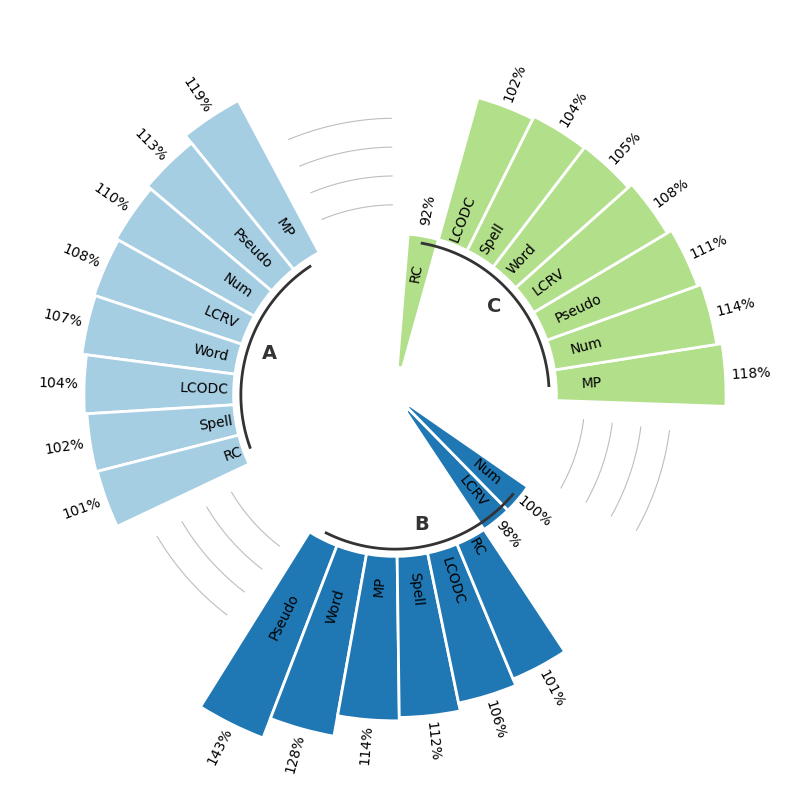

In [55]:
## PLOT ##
measure = 'WIAT'
scale = 'P'
keys = ['RC', 'Num', 'Pseudo', 'Spell', 'Word', 'LCRV', 'LCODC', 'MP']

# get full keys
cols_to_filter = [f'{measure},{measure}_{key}_{scale}' for key in keys]

# get data for plot
grouped_df = get_data_for_circular_plot(keys=cols_to_filter, dx='DX_Subtype_Name', assessment='Child', measure=measure, scale=scale)

# plot
vis.circular_barplot(df=grouped_df, values='ratio_m', labels='score_names', group='DX_Subtype_Name', title='')

### Cognitive Assessment

<Figure size 900x400 with 0 Axes>

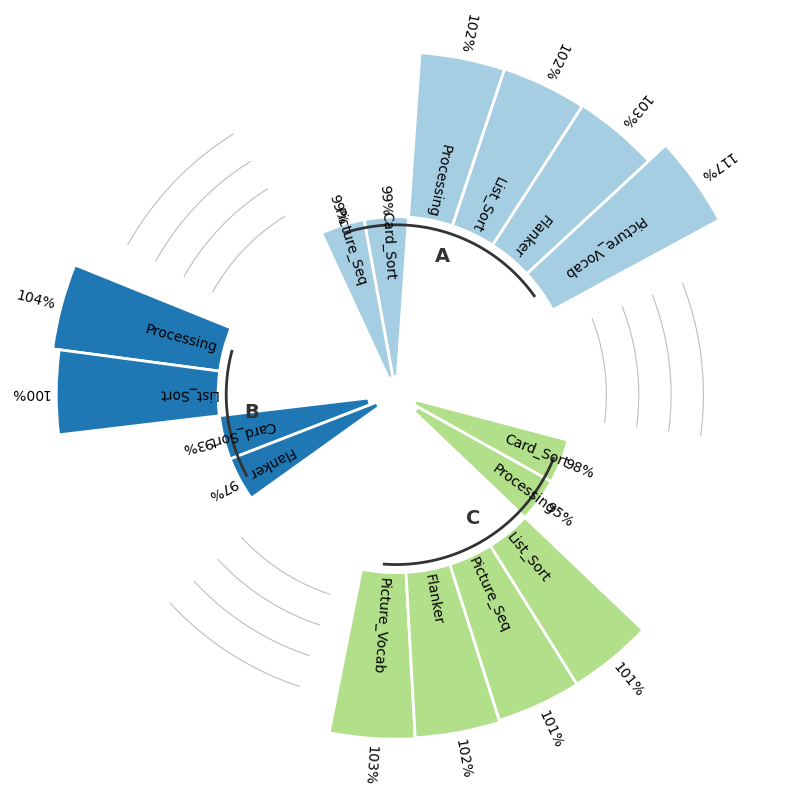

In [61]:
## PLOT ##
measure = 'NIH_final'
scale = 'Stnd'
keys = ['Card_Sort_Age_Corr', 'Flanker_Age_Corr', 'List_Sort_Age_Corr', 
        'Processing_Age_Corr', 'Picture_Vocab_Age_Corr', 'Picture_Seq_Age_Corr']

# get full keys
cols_to_filter = [f'{measure},NIH_{key}_{scale}' for key in keys]

# get data for plot
grouped_df = get_data_for_circular_plot(keys=cols_to_filter, dx='DX_Subtype_Name', assessment='Child', measure=measure, scale=scale)

# rename cols
grouped_df['score_names'] = grouped_df['score_names'].str.replace('NIH_final,NIH_', '').str.replace('_Age_Corr', '')

# plot
vis.circular_barplot(df=grouped_df, values='ratio_m', labels='score_names', group='DX_Subtype_Name', title='')